# Turtle Draw - Pipeline de Visão Computacional

Este notebook contém o desenvolvimento da pipeline de visão computacional utilizada no projeto Turtle Draw.

Objetivos:
- Carregar e visualizar a imagem
- Realizar pré-processamento
- Implementar detecção de bordas manualmente
- Extrair contornos
- Preparar os pontos para movimentação no turtlesim

Bibliotecas utilizadas:
- OpenCV (apenas para carregamento da imagem)
- NumPy
- Matplotlib

## 1. Importar Bibliotecas

In [41]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

%matplotlib inline

print("Bibliotecas importadas com sucesso!")

Bibliotecas importadas com sucesso!


## 2. Carregar e Exibir Imagem

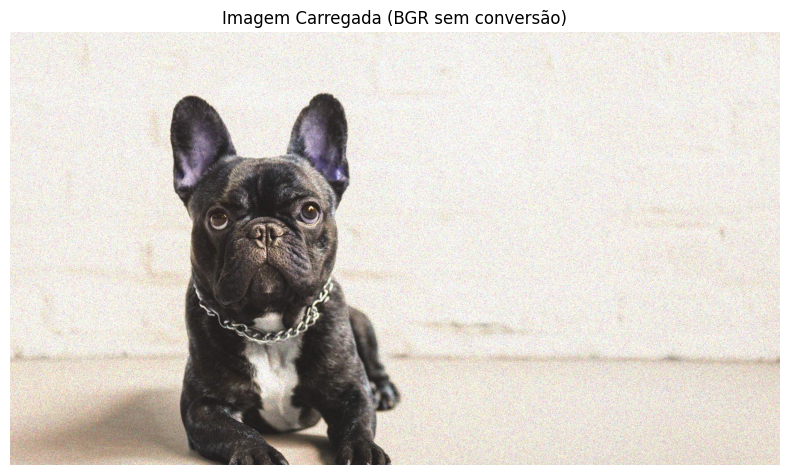

In [42]:
# Carregar imagem
img = cv2.imread("assets/dog.png")

# Mostar a imagem carregada
plt.figure(figsize=(8, 8))
plt.imshow(img)
plt.title('Imagem Carregada (BGR sem conversão)')
plt.axis('off')
plt.tight_layout()
plt.show()

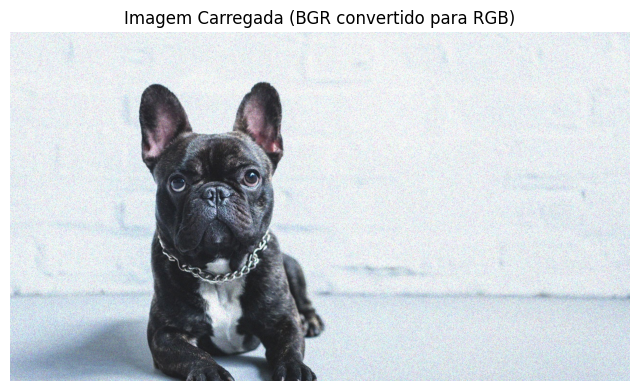

In [ ]:
# Converter BGR para RGB (manualmente)
rgb_img = img[:, :, ::-1]

# Exibir imagem
plt.figure(figsize=(8, 8))
plt.imshow(rgb_img)
plt.title("Imagem Carregada (BGR convertido para RGB)")
plt.axis("off")
plt.show()

In [ ]:
print(f"Shape: {rgb_img.shape}")
print(f"Tipo de dados: {rgb_img.dtype}")

Shape: (720, 1280, 3)
Tipo de dados: uint8


## 3. Pré-processamento

O pré-processamento tem como objetivo preparar a imagem para as etapas posteriores da pipeline de visão computacional, reduzindo informações desnecessárias e facilitando a detecção de bordas.

Imagens originais normalmente possuem ruídos, variações de iluminação, texturas e detalhes que podem dificultar a identificação correta dos contornos principais. Dessa forma, aplicar transformações antes da detecção de bordas ajuda a simplificar a imagem e destacar as estruturas mais importantes.

Nesta etapa, serão realizadas transformações para reduzir a complexidade da imagem e melhorar a qualidade da extração de contornos.

### 3.1. Conversão para Grayscale

A imagem carregada originalmente está no formato RGB, composto por três canais de cor: vermelho (Red), verde (Green) e azul (Blue).

Entretanto, para a detecção de bordas, as informações de cor não são essenciais, sendo o mais importante identificar mudanças de intensidade entre regiões da imagem. Por isso, a imagem foi convertida para **grayscale (tons de cinza)**, simplificando a imagem, reduzindo a complexidade do processamento, reduzindo ruídos de cor e facilitando a análise posterior.

Na imagem em grayscale, cada pixel passa a possuir apenas um valor de intensidade, variando entre preto (0) e branco (255).

A conversão foi implementada manualmente utilizando uma média ponderada dos canais RGB. A fórmula utilizada foi:

> `Gray = 0.299R + 0.587G + 0.114B`

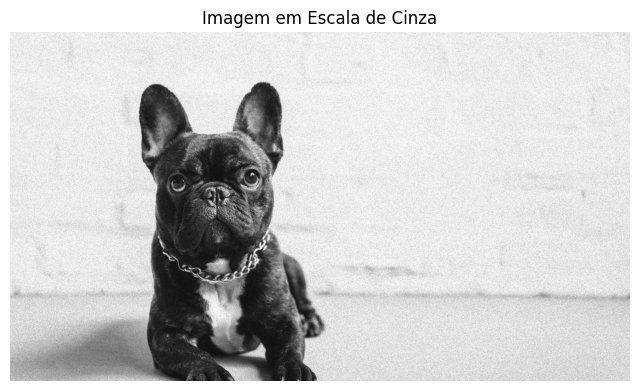

In [ ]:
# 3 canais RBG da imagem multiplicados pelos pesos e somados para obter a intensidade de cinza
gray_img = np.dot(rgb_img[..., :3],[0.299, 0.587, 0.114]).astype(np.uint8)

# Exibir imagem em escala de cinza
plt.figure(figsize=(8, 8))
plt.imshow(gray_img, cmap='gray')
plt.title("Imagem em Escala de Cinza")
plt.axis("off")
plt.show()

In [ ]:
print(f"Shape da imagem grayscale: {gray_img.shape}")
print(f"Tipo de dados: {gray_img.dtype}")

Shape da imagem grayscale: (720, 1280)
Tipo de dados: uint8


Após a conversão, a imagem mantém as informações estruturais necessárias para a detecção de bordas, porém com menor complexidade computacional.

### 3.2. Redução de Ruído

Após a conversão para grayscale, foi aplicada uma etapa de **suavização da imagem**.

A detecção de bordas é altamente sensível a pequenas variações de intensidade, o que pode fazer com que texturas, ruídos e detalhes pouco relevantes sejam identificados como bordas. Como a imagem utilizada possui detalhes como pelos, sombras e variações de iluminação, a suavização ajuda a reduzir essas interferências antes da etapa de detecção.

Foram testadas diferentes abordagens de suavização para entender a que melhor reduziria o ruído da imagem:


#### 3.2.1. Filtro de Média

O filtro de média é uma técnica simples de suavização utilizada para reduzir ruídos e pequenas variações de intensidade na imagem.

Nesse método, cada pixel é substituído pela média dos valores dos pixels vizinhos definidos em uma janela, como por exemplo uma matriz 3x3. Dessa forma, pequenas variações são suavizadas, tornando a imagem menos sensível a detalhes irrelevantes durante a detecção de bordas.

In [ ]:
# Implementação manual do filtro de média
def mean_filter(image, kernel_size=3):

    # Define o tamanho da borda
    pad = kernel_size // 2
    padded_image = np.pad(image, pad, mode='edge') # Adiciona padding na imagem

    # Cria imagem de saída
    filtered_image = np.zeros_like(image)

    # Percorre cada pixel da imagem original
    for i in range(image.shape[0]):
        for j in range(image.shape[1]):

            # Recorda vizinhança 
            neighborhood = padded_image[i:i+kernel_size, j:j+kernel_size]

            filtered_image[i, j] = np.mean(neighborhood) # Calculá a média

    return filtered_image.astype(np.uint8)


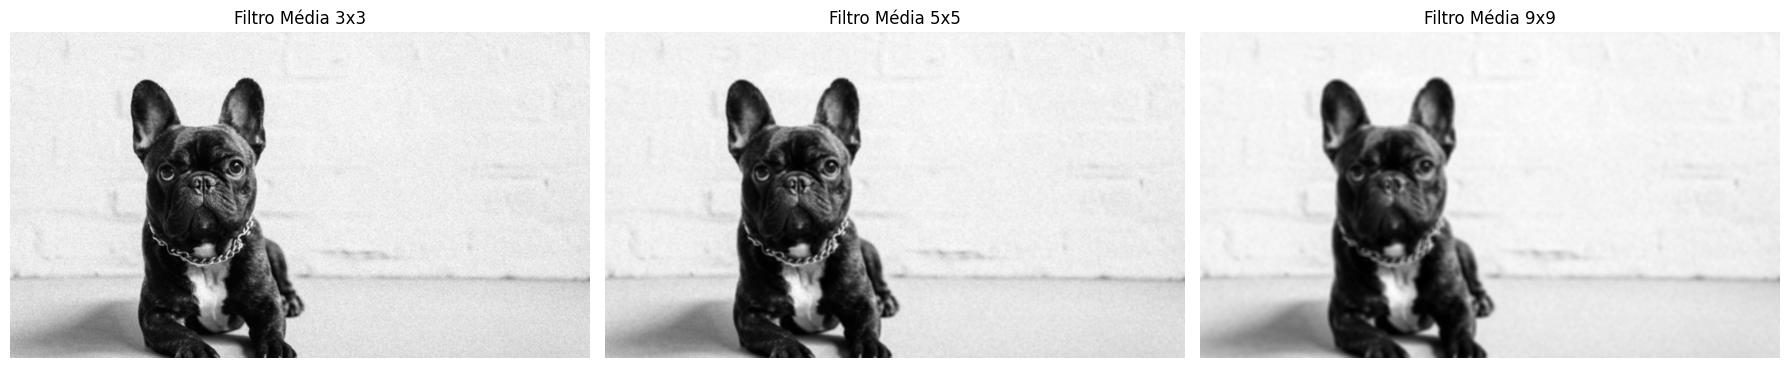

In [48]:
# Aplicar filtros
mean_filtered_3 = mean_filter(gray_img, 3)
mean_filtered_5 = mean_filter(gray_img, 5)
mean_filtered_9 = mean_filter(gray_img, 9)

# Exibir resultados
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Filtro 3x3
axes[0].imshow(mean_filtered_3, cmap='gray')
axes[0].set_title("Filtro Média 3x3")
axes[0].axis("off")

# Filtro 5x5
axes[1].imshow(mean_filtered_5, cmap='gray')
axes[1].set_title("Filtro Média 5x5")
axes[1].axis("off")

# Filtro 9x9
axes[2].imshow(mean_filtered_9, cmap='gray')
axes[2].set_title("Filtro Média 9x9")
axes[2].axis("off")

plt.tight_layout()
plt.show()

A partir das imagens geradas, é possível observar que o filtro de média reduz textura, mas kernels grandes removem detalhes e deixam a imagem mais desfocada.

#### 3.2.2. Filtro Gaussiano

O filtro gaussiano é uma técnica de suavização utilizada para reduzir ruídos e pequenas variações de intensidade na imagem, preservando melhor os contornos principais.

Diferente do filtro de média, no qual todos os pixels da vizinhança possuem o mesmo peso, o filtro gaussiano aplica pesos maiores aos pixels mais próximos do centro da janela. Isso permite uma suavização mais natural, reduzindo ruídos sem causar tanto borramento nas estruturas importantes da imagem.

In [49]:
def gaussian_filter(image):

    # Kernel gaussinao 3x3
    kernel = np.array([
        [1, 2, 1],
        [2, 4, 2],
        [1, 2, 1]
    ]) / 16  # Normaliza o kernel

    pad = 1
    padded_image = np.pad(image, pad, mode='edge') # Adiciona padding na imagem

    # Cria imagem de saída
    filtered_image = np.zeros_like(image, dtype=np.float32)

    # Percorre pixels da imagem original 
    for i in range(image.shape[0]):
        for j in range(image.shape[1]):

            # Recorta vizinhança 
            neighborhood = padded_image[i:i+3, j:j+3]

            filtered_image[i, j] = np.sum(neighborhood * kernel) # Aplica convolução
    
    return filtered_image.astype(np.uint8)

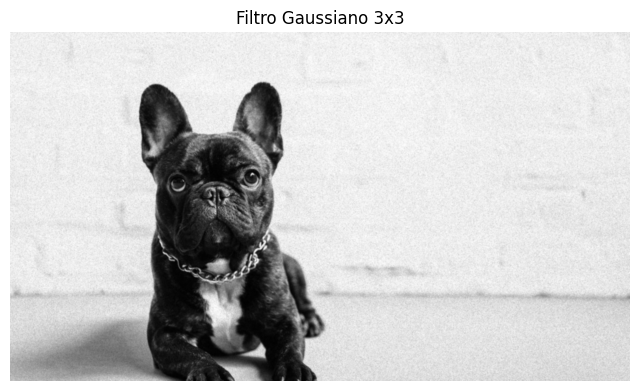

In [50]:
# Aplicar filtro gaussiano
gaussian_filtered = gaussian_filter(gray_img)

# Exibir resultado
plt.figure(figsize=(8, 8))
plt.imshow(gaussian_filtered, cmap='gray')
plt.title("Filtro Gaussiano 3x3")
plt.axis("off")
plt.show()

#### 3.2.2. Comparação dos Filtros

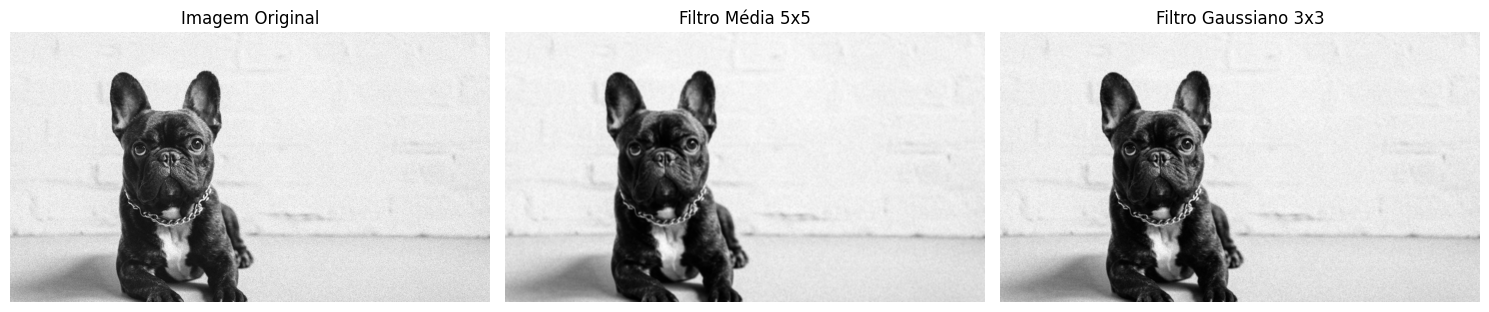

In [51]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(gray_img, cmap='gray')
axes[0].set_title("Imagem Original")
axes[0].axis("off")

axes[1].imshow(mean_filtered_5, cmap='gray')
axes[1].set_title("Filtro Média 5x5")
axes[1].axis("off")

axes[2].imshow(gaussian_filtered, cmap='gray')
axes[2].set_title("Filtro Gaussiano 3x3")
axes[2].axis("off")

plt.tight_layout()
plt.show()

Analisando as imagens obtidas, é possível perceber uma redução de ruídos e texturas da imagem original após a aplicação dos filtros de suavização.

Visualmente, a diferença entre os resultados do filtro de média e do filtro gaussiano não se mostrou muito significativa para esta imagem específica. Isso provavelmente porque a imagem original já possui relativamente pouco ruído, o que faz com que ambos os métodos apresentem resultados semelhantes.

Entretanto, observando com mais atenção, percebe-se que o filtro de média gera um leve borramento adicional nas bordas principais da imagem. Já o filtro gaussiano preserva melhor os contornos importantes devido à utilização de pesos diferentes para os pixels vizinhos, atribuindo maior influência aos pixels mais próximos do centro da janela.

Dessa forma, o **filtro gaussiano** foi escolhido para a pipeline final por apresentar um melhor equilíbrio entre suavização e preservação das estruturas relevantes para a detecção de bordas.

## 4. Detecção de Borda

Após o pré-processamento da imagem, foi realizada a etapa de detecção de bordas para identificar os contornos principais do cachorro que, porteriormente, serão transformados em trajetórias para o turtlesim.

Para isso, foi utilizado o operador de **Sobel**, escolhido por sua simplicidade de implementação e boa capacidade de identificar variações de intensidade na imagem. O método calcula mudanças horizontais e verticais entre os pixels, permitindo destacar regiões onde há transições bruscas de intensidade, que representam as bordas da imagem.

Outros métodos de detecção de bordas foram considerados, como Prewitt, Roberts e Canny. Entretanto, o Sobel apresentou um bom equilíbrio entre qualidade dos resultados e complexidade de implementação para a proposta do projeto.

##### **Operador de Sobel**

O **operador de Sobel** utiliza dois kernels de convolução para calcular as variações de intensidade da imagem nas direções horizontal e vertical.

O kernel $G_x$ detecta mudanças horizontais de intensidade, enquanto o kernel $G_y$ detecta mudanças verticais.

**Kernel para o gradiente horizontal (detecta bordas verticais):**
$$S_x = \begin{bmatrix} -1 & 0 & 1 \\ -2 & 0 & 2 \\ -1 & 0 & 1 \end{bmatrix}$$

$$G_x = S_x * I$$

**Kernel para o gradiente vertical (detecta bordas horizontais):**
$$S_y = \begin{bmatrix} -1 & -2 & -1 \\ 0 & 0 & 0 \\ 1 & 2 & 1 \end{bmatrix}$$

$$G_y = S_y * I$$

In [55]:
# Cálculo do gradiente Gx
def sobel_gx(image):

    # Kernel Gx (3x3)
    kernel = np.array([
        [-1, 0, 1],
        [-2, 0, 2],
        [-1, 0, 1]
    ]) / 8  # Normaliza o kernel

    pad = 1
    padded_image = np.pad(image, pad, mode='edge') # Adiciona padding na imagem

    # Cria imagem de saída
    filtered_image_gx = np.zeros_like(image, dtype=np.float32)

    # Percorre pixels da imagem original 
    for i in range(image.shape[0]):
        for j in range(image.shape[1]):

            # Recorta vizinhança 
            neighborhood = padded_image[i:i+3, j:j+3]

            filtered_image_gx[i, j] = np.sum(neighborhood * kernel) # Aplica convolução
    
    return filtered_image_gx.astype(np.float32)

# Cálculo do gradiente Gy
def sobel_gy(image):

    # Kernel Gy (3x3)
    kernel = np.array([
        [-1, -2, -1],
        [0, 0, 0],
        [1, 2, 1]
    ]) / 8  # Normaliza o kernel

    pad = 1
    padded_image = np.pad(image, pad, mode='edge') # Adiciona padding na imagem

    # Cria imagem de saída
    filtered_image_gy = np.zeros_like(image, dtype=np.float32)

    # Percorre pixels da imagem original 
    for i in range(image.shape[0]):
        for j in range(image.shape[1]):

            # Recorta vizinhança 
            neighborhood = padded_image[i:i+3, j:j+3]

            filtered_image_gy[i, j] = np.sum(neighborhood * kernel) # Aplica convolução
    
    return filtered_image_gy.astype(np.float32)

Após a aplicação dos dois kernels, a magnitude do gradiente é calculada para destacar as regiões com maiores variações de intensidade, correspondendo às bordas da imagem.

$$G = \sqrt{G_x^2 + G_y^2}$$

In [56]:
# Combinação dos gradiente Gx e Gy para obter a magnitude do gradiente
def sobel_filter(image):

    # Aplica os filtros Gx e Gy
    gx_image = sobel_gx(image)
    gy_image = sobel_gy(image)

    # Calcula a magnitude do gradiente
    magnitude = np.sqrt(gx_image**2 + gy_image**2)
    filtered_image = (magnitude / np.max(magnitude) * 255).astype(np.uint8)  # Normaliza para [0, 255]

    return filtered_image.astype(np.uint8)

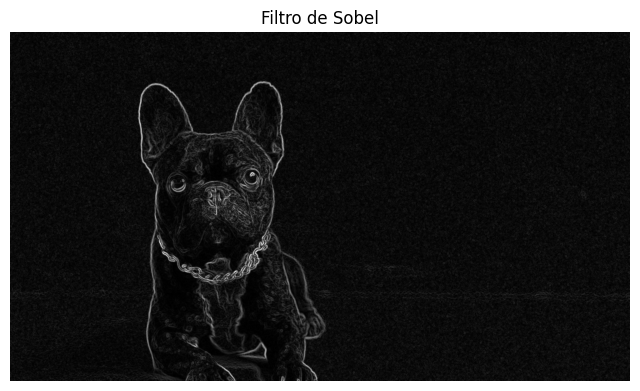

In [57]:
# Aplicar filtro de Sobel
sobel_image = sobel_filter(gaussian_filtered)

# Exibir resultado
plt.figure(figsize=(8, 8))
plt.imshow(sobel_image, cmap='gray')
plt.title("Filtro de Sobel")
plt.axis("off")
plt.show()

### 4.1. Limiarização

Após a aplicação do operador de Sobel, a imagem resultante apresenta diferentes intensidades de borda. Entretanto, nem todas essas bordas são relevantes para o contorno principal da imagem.

Para destacar apenas as bordas mais importantes, foi aplicada uma **etapa de limiarização (thresholding)**, transformando a imagem em uma representação binária composta apenas por pixels pretos e brancos. Nesse processo, pixels com intensidade acima de um valor limite são considerados bordas e recebem valor 255 (branco), enquanto os demais recebem valor 0 (preto). Isso ajuda a reduzir ruídos restantes e facilita a extração dos contornos utilizados posteriormente no turtlesim.

In [65]:
def thresholding(image, limit):

    binary = np.zeros_like(image)
    binary[image > limit] = 255 # Define pixels acima do limite como 255 (branco)

    return binary.astype(np.uint8)

In [86]:
# Aplicar limiarização
thresholding_image_50 = thresholding(sobel_image, 50)
thresholding_image_75 = thresholding(sobel_image, 75)
thresholding_image_85 = thresholding(sobel_image, 85)
thresholding_image_100 = thresholding(sobel_image, 100)

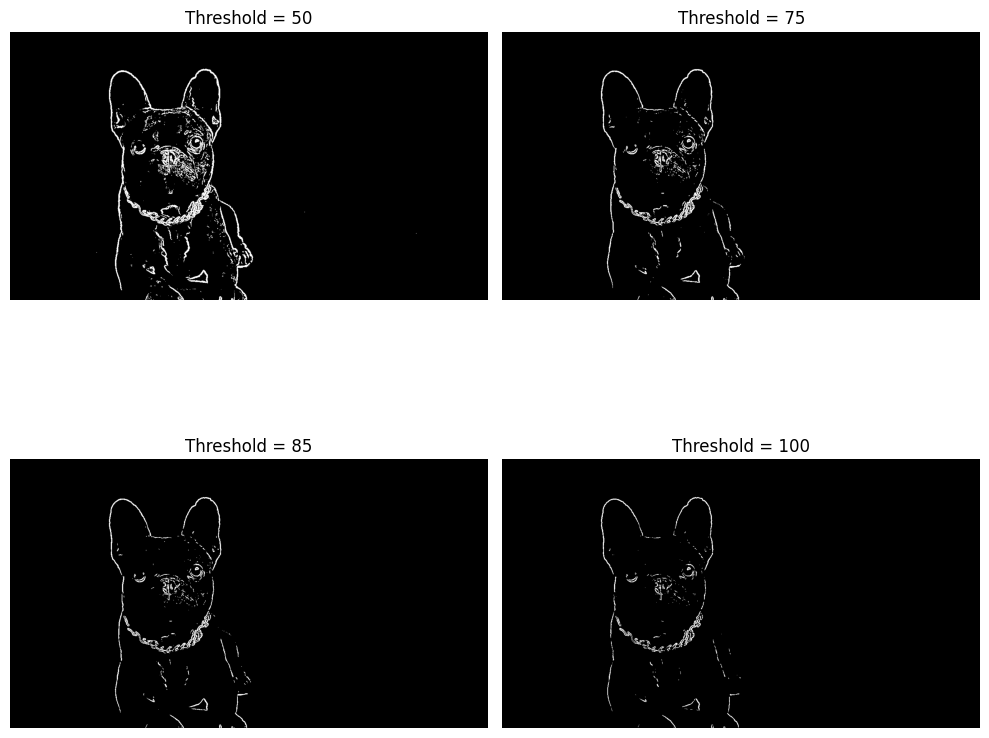

In [88]:
# Exibir resultados
fig, axes = plt.subplots(2, 2, figsize=(10, 10))

# Threshold 50
axes[0, 0].imshow(thresholding_image_50, cmap='gray')
axes[0, 0].set_title("Threshold = 50")
axes[0, 0].axis("off")

# Threshold 75
axes[0, 1].imshow(thresholding_image_75, cmap='gray')
axes[0, 1].set_title("Threshold = 75")
axes[0, 1].axis("off")

# Threshold 85
axes[1, 0].imshow(thresholding_image_85, cmap='gray')
axes[1, 0].set_title("Threshold = 85")
axes[1, 0].axis("off")

# Threshold 100
axes[1, 1].imshow(thresholding_image_100, cmap='gray')
axes[1, 1].set_title("Threshold = 100")
axes[1, 1].axis("off")

plt.tight_layout()
plt.show()

Analisando os diferentes valores de threshold, percebe-se que limites mais baixos preservam uma quantidade maior de detalhes internos da imagem, incluindo texturas, pequenas variações de intensidade e regiões associadas aos pelos do cachorro. Entretanto, isso também aumenta a quantidade de ruídos detectados como bordas.

Por outro lado, valores mais altos reduzem significativamente os detalhes internos e produzem uma imagem mais limpa, focada principalmente no contorno externo do cachorro. Contudo, thresholds elevados também causam perda de continuidade em algumas regiões do contorno, gerando falhas em partes curvas da imagem. Dessa forma, o **threshold de 75** foi escolhido para a pipeline final por apresentar um melhor equilíbrio entre preservação do contorno principal e redução de ruídos e detalhes excessivos.

Apesar da redução significativa de ruídos obtida com a limiarização, ainda permanecem alguns contornos internos da imagem, como detalhes do rosto, olhos e regiões de textura do cachorro. Esses detalhes aparecem porque o operador de Sobel detecta qualquer variação relevante de intensidade na imagem, incluindo mudanças internas de iluminação e textura, e não apenas o contorno externo do objeto.

Métodos adicionais poderiam ser utilizados para reduzir ainda mais esses detalhes internos, como operações morfológicas de erosão e abertura, seleção do maior contorno ou técnicas mais avançadas de segmentação. Essas abordagens poderiam remover pequenas estruturas internas e preservar apenas o contorno externo principal do cachorro.

Entretanto, optou-se por manter parte dessas estruturas na pipeline final por preservar características importantes da imagem, como os contornos dos olhos, nariz e outras regiões faciais do cachorro, tornando o desenho final mais reconhecível e visualmente mais rico.

## 5. Extração de Pontos

Após a etapa de limiarização, a imagem resultante passa a possuir regiões bem definidas correspondentes às bordas detectadas. A partir dessa imagem binária, é possível extrair as coordenadas dos pixels pertencentes aos contornos do cachorro.

Nesta etapa, os pixels brancos da imagem (valor 255) são identificados e convertidos em pontos bidimensionais $(x, y)$. Esses pontos representam as posições das bordas detectadas e serão utilizados posteriormente para gerar a trajetória de movimentação no turtlesim.

In [ ]:
# Extração de pontos a partir da imagem binária
def extract_points(image):

    points = []

    # Percorre linhas
    for y in range(image.shape[0]):

        # Percorre colunas
        for x in range(image.shape[1]):

            # Verifica se pixel pertence à borda
            if image[y, x] == 255:

                points.append((x, y))

    return points

In [ ]:
points = extract_points(thresholding_image_75)
print(f"Quantidade de pontos extraídos: {len(points)}")

Quantidade de pontos extraídos: 12185


A extração direta dos pixels da borda gera uma quantidade muito elevada de pontos, já que cada pixel branco da imagem binária é convertido em uma coordenada. Entretanto, utilizar todos esses pontos pode gerar trajetórias excessivamente detalhadas, aumentando a complexidade da movimentação no turtlesim e mantendo pequenos detalhes e irregularidades da borda.

Por isso, foi realizada uma etapa de **amostragem** dos pontos extraídos, reduzindo a quantidade de coordenadas utilizadas na trajetória final e simplificando o desenho sem perder a estrutura principal do contorno.

In [ ]:
# Amostragem dos pontos para reduzir a quantidade
sampled_points = points[::5]
print(f"Pontos após amostragem: {len(sampled_points)}")

Pontos após amostragem: 2437


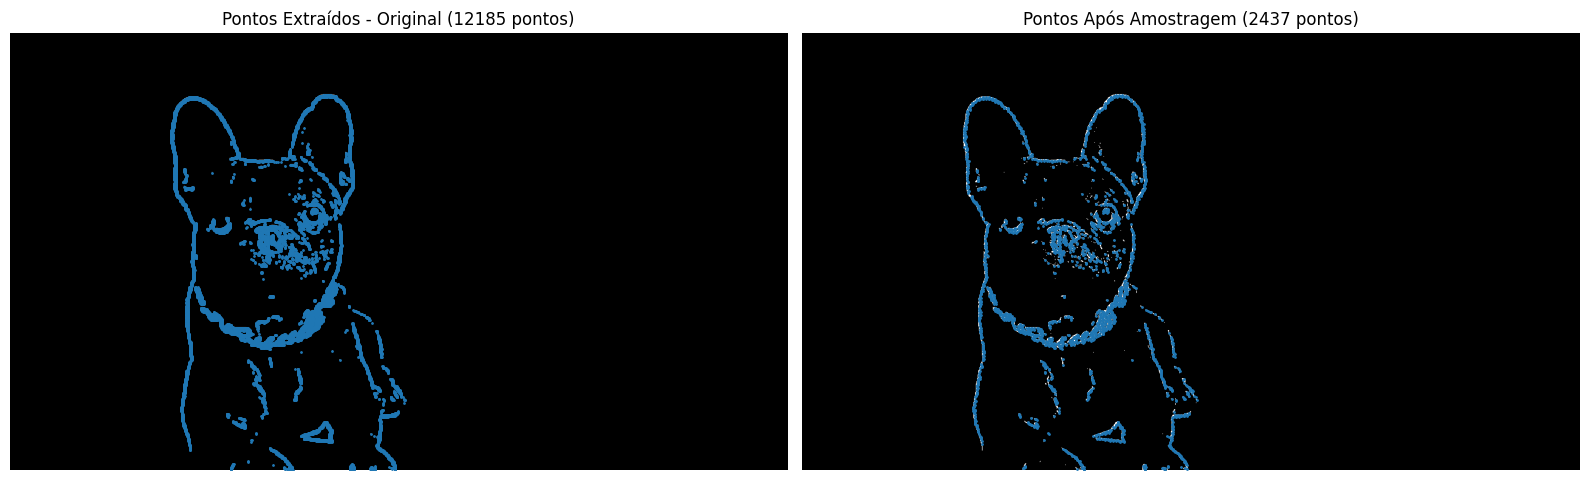

In [99]:
# Pontos originais
x_original = [p[0] for p in points]
y_original = [p[1] for p in points]

# Pontos amostrados
x_sampled = [p[0] for p in sampled_points]
y_sampled = [p[1] for p in sampled_points]

# Comparação visual
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Antes da amostragem
axes[0].imshow(thresholding_image_75, cmap='gray')
axes[0].scatter(x_original, y_original, s=1)
axes[0].set_title(f"Pontos Extraídos - Original ({len(points)} pontos)")
axes[0].axis("off")

# Depois da amostragem
axes[1].imshow(thresholding_image_75, cmap='gray')
axes[1].scatter(x_sampled, y_sampled, s=1)
axes[1].set_title(f"Pontos Após Amostragem ({len(sampled_points)} pontos)")
axes[1].axis("off")

plt.tight_layout()
plt.show()

### 5.1. Salvar os Pontos

Após a extração e amostragem dos pontos, as coordenadas foram armazenadas em um arquivo CSV. Esse formato foi escolhido por permitir uma representação simples e organizada dos pontos da imagem, facilitando sua leitura posterior no ROS2 para movimentação da tartaruga no turtlesim.

Cada linha do arquivo representa uma coordenada $(x, y)$ correspondente a um ponto pertencente ao contorno detectado da imagem.

In [100]:
np.savetxt(
    "points.csv",
    sampled_points,
    fmt="%d",
    delimiter=",",
    header="x,y",
    comments=""
)

print("Pontos salvos em points.csv")

Pontos salvos em points.csv
